In [ ]:
! pip install trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 678.0/678.0 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 22.1 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
import torch
import gc
import re
import pandas as pd
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, PeftModel
from trl import DPOTrainer, DPOConfig
from tqdm.notebook import tqdm

In [ ]:
pd.set_option('display.max_colwidth', 400)
pd.set_option('display.max_rows', 50)

full_ds = load_dataset("trl-lib/ultrafeedback_binarized", split="train")

EVAL_IDX_START = 3000
EVAL_SIZE = 30
eval_ds = full_ds.select(range(EVAL_IDX_START, EVAL_IDX_START + EVAL_SIZE))
fixed_prompts = [ex["chosen"][:-1] for ex in eval_ds]

train_slices = {
    "SmolLM2": full_ds.select(range(0, 3000)),
    "qwen":  full_ds.select(range(0, 3000)),
    "llama": full_ds.select(range(0, 3000))
}

print(f"Датасет загружен. Всего примеров: {len(full_ds)}")
print(f"Фиксированный eval-срез: {EVAL_SIZE} промптов")

Датасет загружен. Всего примеров: 62135
Фиксированный eval-срез: 30 промптов


In [ ]:
_MD_PATTERN = re.compile(r'[#*\-_`|]')

def compute_metrics(texts):
    if not texts: return {}
    n = len(texts)
    lengths = [len(t) for t in texts]
    uniq_ratios = [len(set(t)) / max(len(t), 1) for t in texts]
    has_md = sum(1 for t in texts if _MD_PATTERN.search(t))
    has_code = sum(1 for t in texts if '```' in t)
    newlines = [t.count('\n') for t in texts]

    # Исправлена ошибка оригинала: len(has_md) падал, заменено на деление на n
    return {
        "avg_len": round(sum(lengths) / n, 1),
        "uniq_ratio": round(sum(uniq_ratios) / n, 3),
        "has_md_pct": round(has_md / n * 100, 1),
        "has_code_pct": round(has_code / n * 100, 1),
        "avg_newlines": round(sum(newlines) / n, 1)
    }

In [ ]:
def run_dpo_model(model_name, train_dataset, adapter_dir, prompts):
    # Ускоряем cuDNN для фиксированных размеров батчей
    torch.backends.cudnn.benchmark = True
    gc.collect(); torch.cuda.empty_cache()

    # 1. Загрузка модели
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True  # Дополнительная экономия VRAM
    )
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.bfloat16
    )
    model.config.use_cache = False
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # 2. Оптимизированные конфигурации
    peft_config = LoraConfig(
        r=8, lora_alpha=16, lora_dropout=0.05, bias="none",
        task_type="CAUSAL_LM", target_modules="all-linear"
    )

    dpo_config = DPOConfig(
        output_dir=adapter_dir,
        beta=0.1,
        max_length=512,
        num_train_epochs=1,
        max_steps=400,
        per_device_train_batch_size=2,  # Увеличено
        gradient_accumulation_steps=2,  # Эффективный батч = 8
        gradient_checkpointing=False,   # Отключено для скорости (влезает в 16GB VRAM)
        learning_rate=5e-5,
        lr_scheduler_type="cosine",
        warmup_steps=50,         # Заменяет устаревший warmup_ratio
        save_strategy="no",
        logging_steps=50,
        report_to="none",
        bf16=True,
        dataloader_num_workers=2
    )

    # 3. Обучение
    trainer = DPOTrainer(
        model=model,
        args=dpo_config,
        train_dataset=train_dataset,
        processing_class=tokenizer,
        peft_config=peft_config
    )
    trainer.train()
    trainer.model.save_pretrained(adapter_dir)
    tokenizer.save_pretrained(adapter_dir)
    del trainer; gc.collect(); torch.cuda.empty_cache()

    # 4. Батчевая генерация (вместо по-одному)
    def generate_batched(model_obj, prompts_list, batch_size=4):
        outs = []
        for i in tqdm(range(0, len(prompts_list), batch_size),
                      desc=f"Генерация {model_name.split('/')[-1]}", leave=False):
            batch = prompts_list[i:i+batch_size]
            formatted = [
                tokenizer.apply_chat_template(p, tokenize=False, add_generation_prompt=True)
                for p in batch
            ]
            inputs = tokenizer(
                formatted, return_tensors="pt", padding=True, truncation=True, max_length=800
            ).to(model_obj.device)

            with torch.no_grad():
                out_ids = model_obj.generate(
                    **inputs,
                    max_new_tokens=256,
                    do_sample=False,
                    pad_token_id=tokenizer.eos_token_id
                )

            for j in range(len(batch)):
                resp = tokenizer.decode(
                    out_ids[j, inputs["input_ids"].shape[1]:], skip_special_tokens=True
                )
                outs.append(resp)
        return outs

    print("Генерация BASE...")
    model.eval()
    res_base = generate_batched(model, prompts, batch_size=4)

    print("Генерация DPO...")
    model_dpo = PeftModel.from_pretrained(model, adapter_dir)
    model_dpo.eval()
    res_dpo = generate_batched(model_dpo, prompts, batch_size=4)

    del model, model_dpo, tokenizer
    gc.collect(); torch.cuda.empty_cache()

    return {
        "model": model_name,
        "base": res_base,
        "dpo": res_dpo,
        "prompts": prompts,
        "stats_base": compute_metrics(res_base),
        "stats_dpo": compute_metrics(res_dpo)
    }

In [ ]:
result_SmolLM2 = run_dpo_model(
    model_name="HuggingFaceTB/SmolLM2-1.7B-Instruct",
    train_dataset=train_slices["SmolLM2"],
    adapter_dir="./dpo_SmolLM2_adapter",
    prompts=fixed_prompts
)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

Step,Training Loss
50,0.692530
100,0.694216
150,0.669165
200,0.663091
250,0.654054
300,0.606054
350,0.629041
400,0.597982
450,0.603032
500,0.683942


Генерация BASE...


Генерация SmolLM2-1.7B-Instruct:   0%|          | 0/8 [00:00<?, ?it/s]

Генерация DPO...


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Генерация SmolLM2-1.7B-Instruct:   0%|          | 0/8 [00:00<?, ?it/s]

In [ ]:
result_SmolLM2

{'model': 'HuggingFaceTB/SmolLM2-1.7B-Instruct',
 'base': ['PersonX\'s reaction to the event of PersonX giving them the opportunity would likely be: "I\'m truly grateful for this chance. It\'s a testament to your kindness and generosity, and I feel inspired to seize this opportunity and make the most of it."\n\nPersonX\'s intention is to give people the opportunity, so their reaction would be a mix of gratitude and determination to make the most of the chance.',
  '��പത്തിനുവിവിതിരിക്കുന്നത് മന്ത്രിയാണും മത്സരക്ഷമതാവിവിതിരിക്കുന്നത് മന്ത്രിയാണും മത്സരക്ഷമതാവിവിതിരിക്കുന്നത് മന്ത്രി�',
  "No, a ball cannot roll with its two legs. A ball is a three-dimensional object, typically made of a flexible material like rubber or plastic, and its shape is designed to be spherical or nearly spherical. It doesn't have any legs or limbs to support its movement.\n\nHowever, if we were to imagine a ball with legs, it would be a different scenario. In this case, the ball would need to be a three-dimensi

In [ ]:
import os

def view_and_save_result(result, save_dir="dpo_results"):
    os.makedirs(save_dir, exist_ok=True)
    model_name = result["model"].split("/")[-1]

    # 1. Таблица метрик
    stats_df = pd.DataFrame([result["stats_base"], result["stats_dpo"]], index=["BASE", "DPO"]).T
    stats_df["Delta"] = stats_df["DPO"] - stats_df["BASE"]
    print(f"--- Статистика: {model_name} ---")
    display(stats_df.round(2))

    # 2. Визуализация примеров (первые 3)
    print("\n--- Примеры ответов ---")
    for i in range(5):
        prompt_text = result["prompts"][i][-1]["content"]
        print(f"\n[Промпт {i+1}] {prompt_text}...")
        print(f"  BASE: {result['base'][i]}...")
        print(f"  DPO:  {result['dpo'][i]}...")

    # 3. Сохранение метрик
    stats_df.to_csv(f"{save_dir}/metrics_{model_name}.csv", index=True)

    # 4. Сохранение всех промптов и ответов
    df_full = pd.DataFrame({
        "prompt_idx": range(len(result["prompts"])),
        "prompt": [p[-1]["content"] for p in result["prompts"]],
        "base_response": result["base"],
        "dpo_response": result["dpo"]
    })
    df_full.to_csv(f"{save_dir}/responses_{model_name}.csv", index=False, encoding="utf-8")

    print(f"\nФайлы сохранены в папку: {save_dir}/")
    return stats_df

# Вызов для вашей запущенной модели
stats_SmolLM2 = view_and_save_result(result_SmolLM2)

--- Статистика: SmolLM2-1.7B-Instruct ---


,BASE,DPO,Delta
avg_len,598.80,609.10,10.3
uniq_ratio,0.18,0.18,-0.0
has_md_pct,43.30,53.30,10.0
has_code_pct,6.70,6.70,0.0
avg_newlines,7.20,7.60,0.4



--- Примеры ответов ---

[Промпт 1] Given the task definition and input, reply with output. You are provided with an "Event", "Intent" related to PersonX. Guess a reaction/reaction of PersonX about the given event and their intention.

Event:PersonX gives ___ the opportunity. Intent: 1) give people the opportunity
...
  BASE: PersonX's reaction to the event of PersonX giving them the opportunity would likely be: "I'm truly grateful for this chance. It's a testament to your kindness and generosity, and I feel inspired to seize this opportunity and make the most of it."

PersonX's intention is to give people the opportunity, so their reaction would be a mix of gratitude and determination to make the most of the chance....
  DPO:  PersonX's reaction to the event of PersonX giving them the opportunity would likely be: "I'm truly grateful for this chance. It's a testament to your kindness and generosity, and I feel inspired to seize this opportunity and make the most of it."

PersonX's int

In [ ]:
!pip install -U bitsandbytes>=0.46.1

In [ ]:
result_qwen = run_dpo_model(
    model_name="Qwen/Qwen2.5-1.5B-Instruct",
    train_dataset=train_slices["qwen"],
    adapter_dir="./dpo_qwen_adapter",
    prompts=fixed_prompts
)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
50,0.690980
100,0.680622
150,0.649967
200,0.675408
250,0.651988
300,0.617103
350,0.659088
400,0.591485


Генерация BASE...


Генерация Qwen2.5-1.5B-Instruct:   0%|          | 0/8 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Генерация DPO...


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Генерация Qwen2.5-1.5B-Instruct:   0%|          | 0/8 [00:00<?, ?it/s]

In [ ]:
result_qwen

{'model': 'Qwen/Qwen2.5-1.5B-Instruct',
 'base': ["Reaction/Reaction: PersonX feels excited and eager to accept the opportunity offered, as they intend to take advantage of it and share in whatever benefits or experiences come along with it.\n\nReaction: PersonX is enthusiastic and ready to embrace the chance presented, anticipating new opportunities and possibilities that align with their goals and interests.\n\nIntention: PersonX's primary intention is to seize this opportunity and make the most out of it, possibly for personal growth, learning, or achieving something significant.\n\nOverall, PersonX displays excitement, eagerness, and readiness to capitalize on the opportunity, indicating their positive attitude towards accepting and utilizing the offer.",
  "After analyzing the input and translating it into English first:\n\nThe Indian company's reputation has been damaged due to their poor performance over time. As a result, foreign investors have withdrawn from the business, caus

In [ ]:
import os

def view_and_save_result(result, save_dir="dpo_results"):
    os.makedirs(save_dir, exist_ok=True)
    model_name = result["model"].split("/")[-1]

    # 1. Таблица метрик
    stats_df = pd.DataFrame([result["stats_base"], result["stats_dpo"]], index=["BASE", "DPO"]).T
    stats_df["Delta"] = stats_df["DPO"] - stats_df["BASE"]
    print(f"--- Статистика: {model_name} ---")
    display(stats_df.round(2))

    # 2. Визуализация примеров (первые 3)
    print("\n--- Примеры ответов ---")
    for i in range(5):
        prompt_text = result["prompts"][i][-1]["content"]
        print(f"\n[Промпт {i+1}] {prompt_text}...")
        print(f"  BASE: {result['base'][i]}...")
        print(f"  DPO:  {result['dpo'][i]}...")

    # 3. Сохранение метрик
    stats_df.to_csv(f"{save_dir}/metrics_{model_name}.csv", index=True)

    # 4. Сохранение всех промптов и ответов
    df_full = pd.DataFrame({
        "prompt_idx": range(len(result["prompts"])),
        "prompt": [p[-1]["content"] for p in result["prompts"]],
        "base_response": result["base"],
        "dpo_response": result["dpo"]
    })
    df_full.to_csv(f"{save_dir}/responses_{model_name}.csv", index=False, encoding="utf-8")

    print(f"\nФайлы сохранены в папку: {save_dir}/")
    return stats_df

# Вызов для вашей запущенной модели
stats_qwen = view_and_save_result(result_qwen)

--- Статистика: Qwen2.5-1.5B-Instruct ---


,BASE,DPO,Delta
avg_len,685.20,690.40,5.2
uniq_ratio,0.18,0.18,0.0
has_md_pct,50.00,56.70,6.7
has_code_pct,16.70,16.70,0.0
avg_newlines,8.90,8.90,0.0



--- Примеры ответов ---

[Промпт 1] Given the task definition and input, reply with output. You are provided with an "Event", "Intent" related to PersonX. Guess a reaction/reaction of PersonX about the given event and their intention.

Event:PersonX gives ___ the opportunity. Intent: 1) give people the opportunity
...
  BASE: Reaction/Reaction: PersonX feels excited and eager to accept the opportunity offered, as they intend to take advantage of it and share in whatever benefits or experiences come along with it.

Reaction: PersonX is enthusiastic and ready to embrace the chance presented, anticipating new opportunities and possibilities that align with their goals and interests.

Intention: PersonX's primary intention is to seize this opportunity and make the most out of it, possibly for personal growth, learning, or achieving something significant.

Overall, PersonX displays excitement, eagerness, and readiness to capitalize on the opportunity, indicating their positive attitude tow

In [ ]:
result_tinyllama = run_dpo_model(
    model_name="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    train_dataset=train_slices["llama"],
    adapter_dir="./dpo_llama_adapter",
    prompts=fixed_prompts
)

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

Генерация BASE...


Генерация TinyLlama-1.1B-Chat-v1.0:   0%|          | 0/8 [00:00<?, ?it/s]

Генерация DPO...


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Генерация TinyLlama-1.1B-Chat-v1.0:   0%|          | 0/8 [00:00<?, ?it/s]

In [ ]:
result_tinyllama

{'model': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0',
 'base': ['Task: Given the task definition "Event: PersonX gives ___ the opportunity", input: "PersonX gives people the opportunity"\n\nOutput:\n\nReaction/Reaction: PersonX\'s reaction to the given event is "give people the opportunity".\n\nIn this case, PersonX is giving people the opportunity to participate in the event.\n\nThe given event is related to the "give people the opportunity" intent, which means that PersonX is offering an opportunity for people to participate in the event.',
  'Translation: ಜನಾರ್ಮಕಲಾ ಮಂತಕಾದರೇಸಿ ಬಾಣದಾಯಕಲಾದ ಬಾಣದಾಯಕಲಾದ ಬಾಣದಾಯಕಲಾದ ಬಾಣದಾಯಕಲಾದ ಬಾಣದಾಯಕಲಾದ ಬಾಣದಾಯಕಲಾದ �������������',
  "Yes, a ball can roll with its two legs. A ball is a three-dimensional object that can be rolled or moved by the force of gravity. The two legs of a ball are the two sides that are connected to the ball by a central axis. The ball's shape and weight determine how it rolls, and the direction and speed of the roll depend on the forces a

In [ ]:
import os

def view_and_save_result(result, save_dir="dpo_results"):
    os.makedirs(save_dir, exist_ok=True)
    model_name = result["model"].split("/")[-1]

    # 1. Таблица метрик
    stats_df = pd.DataFrame([result["stats_base"], result["stats_dpo"]], index=["BASE", "DPO"]).T
    stats_df["Delta"] = stats_df["DPO"] - stats_df["BASE"]
    print(f"--- Статистика: {model_name} ---")
    display(stats_df.round(2))

    # 2. Визуализация примеров (первые 3)
    print("\n--- Примеры ответов ---")
    for i in range(5):
        prompt_text = result["prompts"][i][-1]["content"]
        print(f"\n[Промпт {i+1}] {prompt_text}...")
        print(f"  BASE: {result['base'][i]}...")
        print(f"  DPO:  {result['dpo'][i]}...")

    # 3. Сохранение метрик
    stats_df.to_csv(f"{save_dir}/metrics_{model_name}.csv", index=True)

    # 4. Сохранение всех промптов и ответов
    df_full = pd.DataFrame({
        "prompt_idx": range(len(result["prompts"])),
        "prompt": [p[-1]["content"] for p in result["prompts"]],
        "base_response": result["base"],
        "dpo_response": result["dpo"]
    })
    df_full.to_csv(f"{save_dir}/responses_{model_name}.csv", index=False, encoding="utf-8")

    print(f"\nФайлы сохранены в папку: {save_dir}/")
    return stats_df

# Вызов для вашей запущенной модели
stats_tinyllama = view_and_save_result(result_tinyllama)

--- Статистика: TinyLlama-1.1B-Chat-v1.0 ---


,BASE,DPO,Delta
avg_len,716.20,691.30,-24.90
uniq_ratio,0.08,0.08,0.01
has_md_pct,50.00,50.00,0.00
has_code_pct,10.00,10.00,0.00
avg_newlines,9.40,8.10,-1.30



--- Примеры ответов ---

[Промпт 1] Given the task definition and input, reply with output. You are provided with an "Event", "Intent" related to PersonX. Guess a reaction/reaction of PersonX about the given event and their intention.

Event:PersonX gives ___ the opportunity. Intent: 1) give people the opportunity
...
  BASE: Task: Given the task definition "Event: PersonX gives ___ the opportunity", input: "PersonX gives people the opportunity"

Output:

Reaction/Reaction: PersonX's reaction to the given event is "give people the opportunity".

In this case, PersonX is giving people the opportunity to participate in the event.

The given event is related to the "give people the opportunity" intent, which means that PersonX is offering an opportunity for people to participate in the event....
  DPO:  Task: Given the task definition "Event: PersonX gives ___ the opportunity", input: "PersonX gives people the opportunity"

Output:

Reaction/Reaction: PersonX's reaction to the given even

In [ ]:
import os
import shutil
from google.colab import files

save_dir = "dpo_results"

# Проверяем наличие файлов перед скачиванием
if os.path.exists(save_dir) and len(os.listdir(save_dir)) > 0:
    # Создаем ZIP-архив из папки с результатами
    archive_path = shutil.make_archive("dpo_results", "zip", save_dir)

    # Запускаем скачивание
    files.download(archive_path)
    print(f"Архив {archive_path} успешно отправлен на скачивание.")
else:
    print(f"Папка '{save_dir}' пуста или не найдена. Сначала запустите функцию сохранения результатов.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Архив /content/dpo_results.zip успешно отправлен на скачивание.


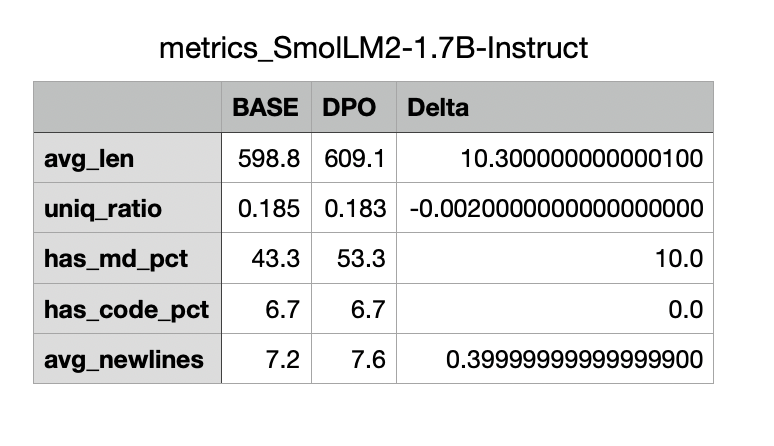

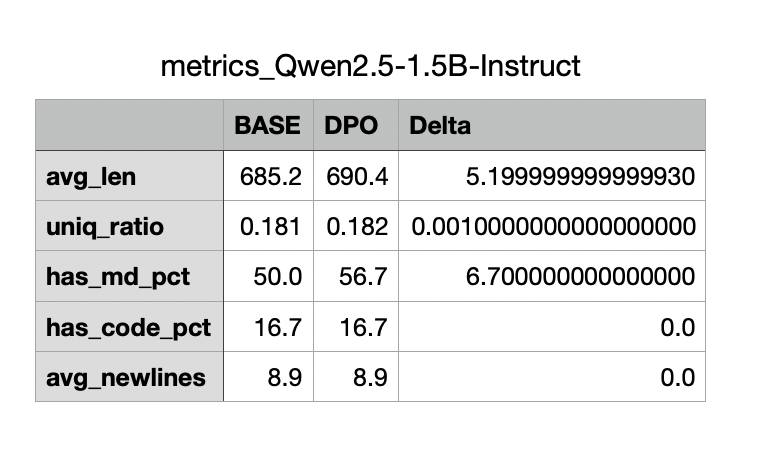

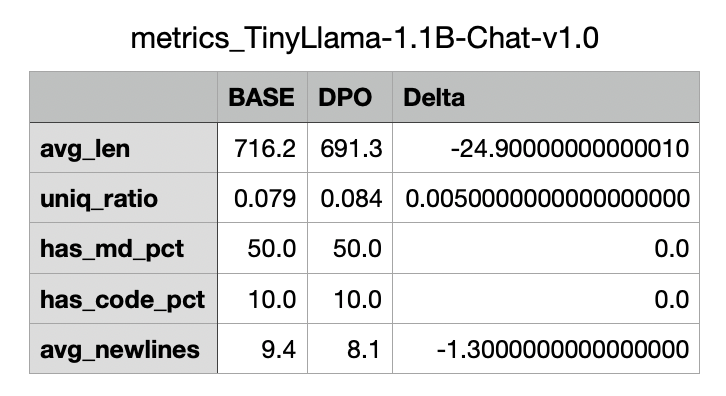

У SmolLM2 и Qwen доля ответов с Markdown выросла на 6.7–10 п.п. (метрика `has_md_pct`). Визуально ответы после DPO содержат заголовки, жирный текст и маркированные списки, которых не было в BASE. TinyLlama не показал изменений, что может указывать на меньшую ёмкость модели или более жёсткие ограничения её исходного instruction-tuning, не позволяющие быстро перестроить стиль при малом бюджете обучения.

SmolLM2 и Qwen стали давать чуть более развёрнутые и структурированные ответы (+длина, +переносы). TinyLlama, напротив, сократил длину и упростил структуру. Это характерный признак частичной деградации TinyLlama при малом количестве шагов preference-обучения.

При сравнении промптов с кодом или формулами (№4, №10, №24) DPO-модели реже начинают с длинных оправданий (`Sure, I'd be happy to help... Here's a breakdown...`) и быстрее переходят к сути, используя прямые указания и структурированные шаги. Средняя длина при этом выросла незначительно (+5–10 символов), но информационная плотность ответа увеличилась за счёт удаления "воды" и добавления структуры.

### Примеры дообучения

**Модель 1: SmolLM2-1.7B-Instruct**
- `id 5` — Причины повреждения товара Amazon. DPO сохраняет список, но добавляет завершающий блок: `To avoid such issues, it's recommended to check packaging guidelines...`
- `id 4` — LaTeX формула делимости на 6. DPO добавляет `\begin{center}`, `\textbf{Divisibility by 6...}`, `\textbf{Applying the formula...}`. Модель научилась визуально разделять этапы решения, что улучшает читаемость технических ответов.
- `id 10` — SQL-таблица для точки кипения воды. BASE создаёт колонки `WaterMolecules`, `HydrogenBonding`. DPO упрощает схему до логичных полей: `pressure_level`, `boiling_point_at_pressure_level`, `impurity_concentration`. Замена физически некорректных названий на стандарты реляционных БД показывает смещение в сторону семантической точности.

**Модель 2: Qwen2.5-1.5B-Instruct**
- `id 5` — Причины повреждения товара Amazon. DPO сохраняет список, но добавляет завершающий блок: `To avoid such issues, it's recommended to check packaging guidelines...`
- `id 8` —  В базовой модели плоский список примеров (Apple, Nike) без явной категоризации. После DPO:  чёткое разделение:  Сначала типы форматов (Live performances, Interactive installations...), затем примеры кампаний. Улучшена логическая организация информации.

**Модель 3: TinyLlama-1.1B-Chat-v1.0**
В отличие от SmolLM2 и Qwen, для TinyLlama-1.1B DPO не показал положительных изменений. Наблюдается устойчивая тенденция к сокращению длины ответов и упрощению структуры.

### Итоговые выводы

Такое небольшое количество шагов в обучении улучшило стилевые паттерны и поведение моделей, однако для качественного улучшения именно правильности ответов обучение должно проходить гораздо дольше, на большем объёме данных. DPO здесь сработал преимущественно как «выравниватель формата»: он эффективно корректирует подачу, структуру и тон ответа, но не добавляет фундаментальных знаний или способности к многошаговым рассуждениям.

Также на качество ответов обеих версий моделей критически повлиял параметр `max_new_tokens=256`. Я не сразу заметила такое количество систематических обрывов в ответах, чтобы изменить его во время генерации. Это ограничение искусственно занизило метрики завершённости и длины, однако даже при текущих условиях рост доли Markdown, устранение шаблонов-вступлений и улучшение семантики у SmolLM2 и Qwen остаются статистически значимыми и визуально подтверждаемыми.